# main notebook

### imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

TRAIN_PATH= '../fer2013/preprocessed/train'
TEST_PATH= '../fer2013/preprocessed/test'
FEATURES_DIR  = '../data/features'
MODEL_PATH    = '../data/models/mlp_model.keras'
SCALER_PATH   = '../data/features/scaler.pkl'
BLAZEFACE_PATH= '../modules/models/blaze_face_short_range.tflite'

CLASS_NAMES   = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
FACE_SIZE     = (64, 64)

print('Imports OK')
print(f'Classes : {CLASS_NAMES}')
print(f'Features: {FEATURES_DIR}')
print(f'Model   : {MODEL_PATH}')

Imports OK
Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Features: ../data/features
Model   : ../data/models/mlp_model.keras


### Preprocessing

In [2]:
for split, path in [('Train', TRAIN_PATH), ('Test', TEST_PATH)]:
    classes = sorted(os.listdir(path))
    total   = sum(len(os.listdir(os.path.join(path, c))) for c in classes)
    print(f'{split}: {total:,} images across {len(classes)} classes → {classes}')

assert sorted(os.listdir(TRAIN_PATH)) == sorted(os.listdir(TEST_PATH)), \
    'Train/test class folders do not match!'
print('\n Class folders match between train and test')

Train: 28,709 images across 7 classes → ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test: 7,178 images across 7 classes → ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

 Class folders match between train and test


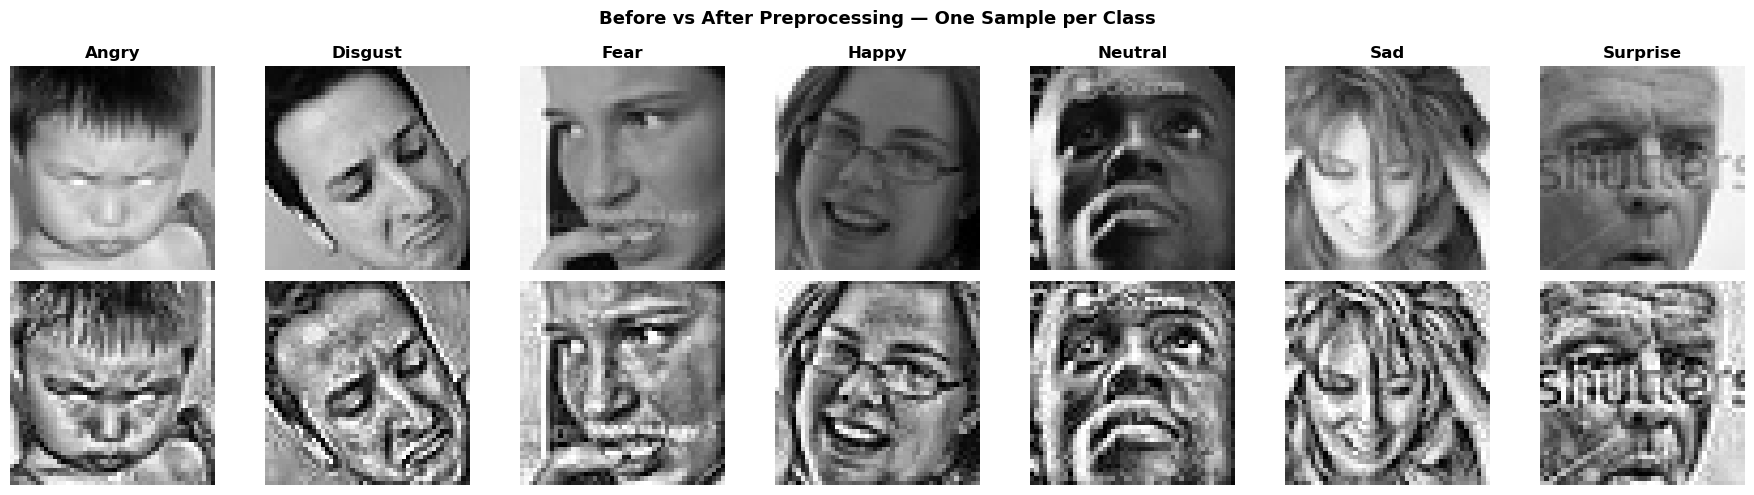

Saved


In [3]:
# ── Before / After preprocessing visualisation ────────────────────────────────
# Shows one sample per class: raw image vs preprocessed image

RAW_PATH = '../fer2013/train'

fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(18, 5))
fig.suptitle('Before vs After Preprocessing — One Sample per Class', fontsize=13, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES):
    # Raw
    raw_dir   = os.path.join(RAW_PATH, cls)
    prep_dir  = os.path.join(TRAIN_PATH, cls)

    fname = sorted(os.listdir(prep_dir))[0]

    raw_img  = cv2.imread(os.path.join(raw_dir,  fname), cv2.IMREAD_GRAYSCALE)
    prep_img = cv2.imread(os.path.join(prep_dir, fname), cv2.IMREAD_GRAYSCALE)

    for row, (img, label) in enumerate([(raw_img, 'Raw'), (prep_img, 'Preprocessed')]):
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls.capitalize(), fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=10)

plt.tight_layout()
os.makedirs('../results/visualizations', exist_ok=True)
plt.savefig('../results/visualizations/preprocessing_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

### Feature Extraction

In [4]:
# ── Load features ─────────────────────────────────────────────────────────────
X_train_raw = np.load(os.path.join(FEATURES_DIR, 'train_X.npy'))
y_train     = np.load(os.path.join(FEATURES_DIR, 'train_y.npy'))
X_test_raw  = np.load(os.path.join(FEATURES_DIR, 'test_X.npy'))
y_test      = np.load(os.path.join(FEATURES_DIR, 'test_y.npy'))

print('Feature arrays loaded:')
print(f'  X_train : {X_train_raw.shape}  dtype={X_train_raw.dtype}')
print(f'  y_train : {y_train.shape}      unique labels={np.unique(y_train)}')
print(f'  X_test  : {X_test_raw.shape}   dtype={X_test_raw.dtype}')
print(f'  y_test  : {y_test.shape}       unique labels={np.unique(y_test)}')

assert X_train_raw.shape[1] == X_test_raw.shape[1], 'Feature dimensions mismatch!'
assert len(np.unique(y_train)) == len(CLASS_NAMES), 'Wrong number of classes in train!'
print('\n Feature arrays verified')

Feature arrays loaded:
  X_train : (28709, 1764)  dtype=float32
  y_train : (28709,)      unique labels=[0 1 2 3 4 5 6]
  X_test  : (7178, 1764)   dtype=float32
  y_test  : (7178,)       unique labels=[0 1 2 3 4 5 6]

 Feature arrays verified


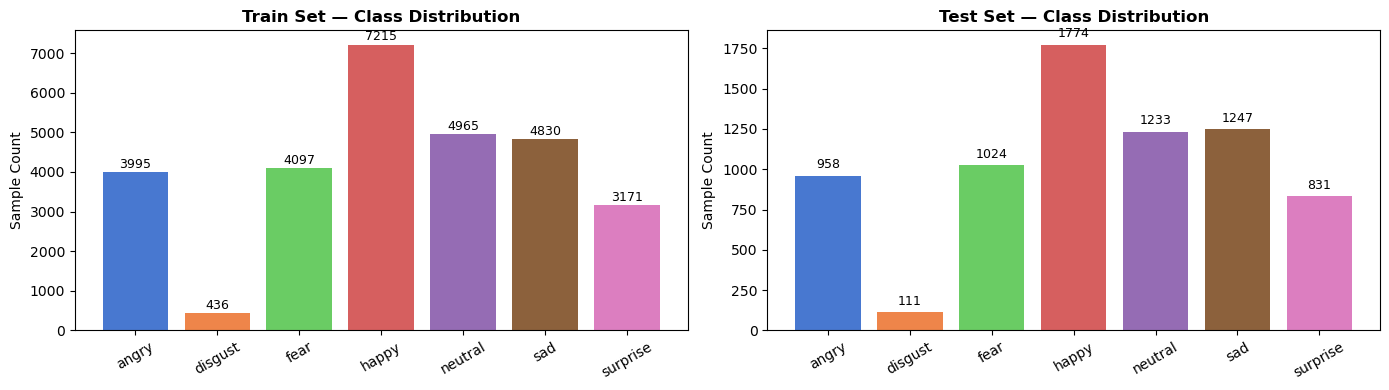

Saved


In [5]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (y, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = [np.sum(y == i) for i in range(len(CLASS_NAMES))]
    bars   = ax.bar(CLASS_NAMES, counts, color=sns.color_palette('muted', len(CLASS_NAMES)))
    ax.set_title(f'{title} Set — Class Distribution', fontweight='bold')
    ax.set_ylabel('Sample Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(cnt), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/visualizations/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

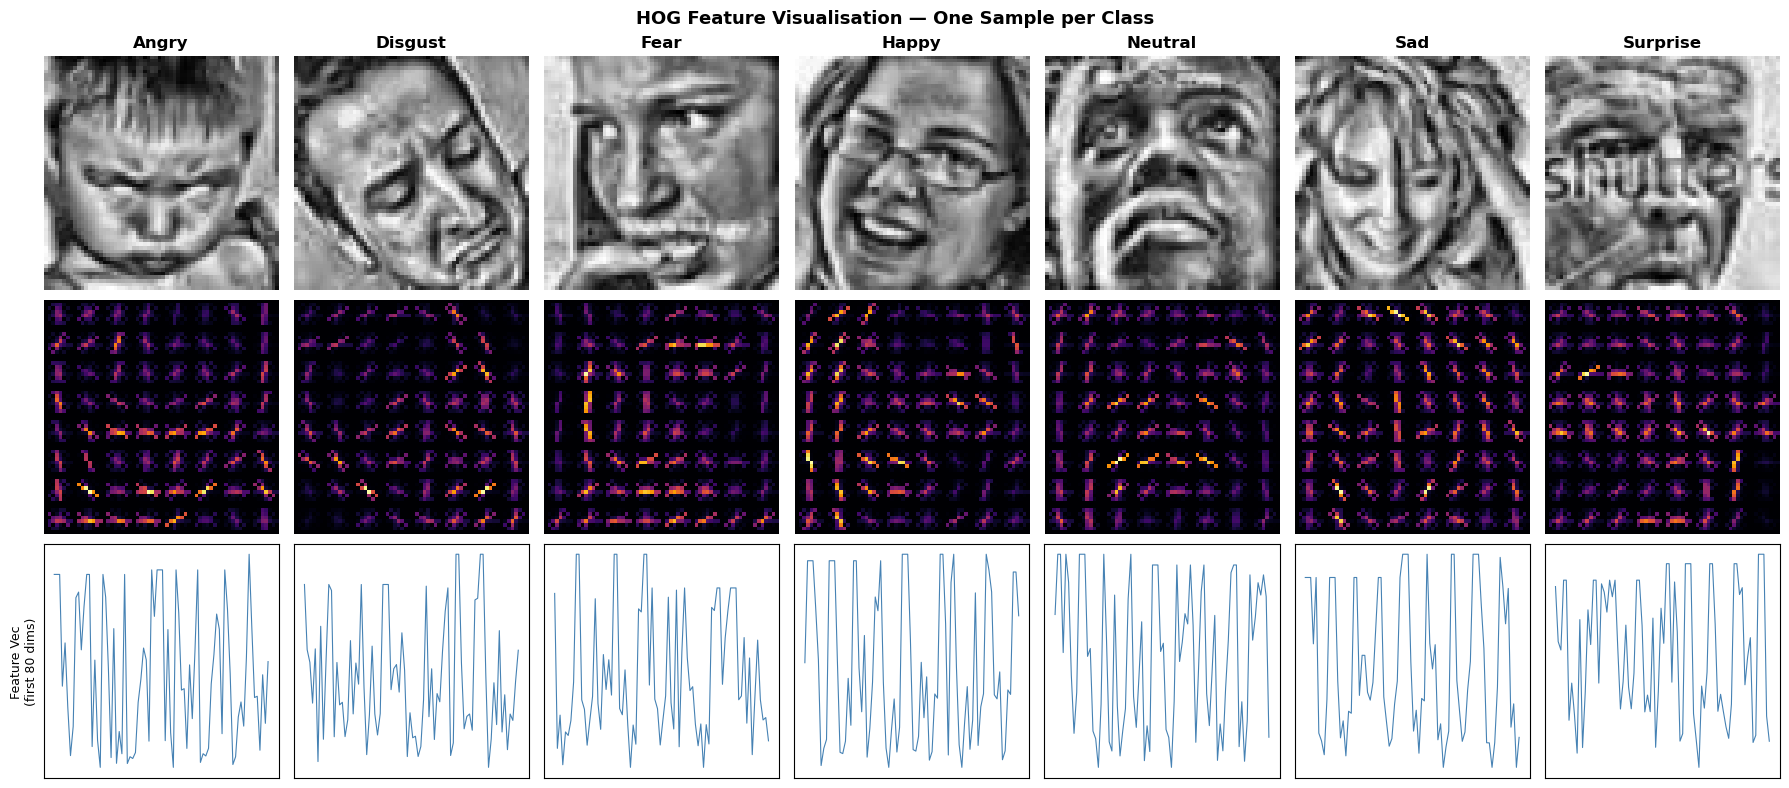

Saved 


In [6]:
# ── HOG feature visualisation — one sample per class ─────────────────────────
fig, axes = plt.subplots(3, len(CLASS_NAMES), figsize=(18, 8))
fig.suptitle('HOG Feature Visualisation — One Sample per Class', fontsize=13, fontweight='bold')

for col, (cls, idx) in enumerate(zip(CLASS_NAMES, range(len(CLASS_NAMES)))):
    # Pick first sample of this class from train
    sample_idx = np.where(y_train == idx)[0][0]
    feat_vec   = X_train_raw[sample_idx]

    # Get the actual image for display
    cls_dir  = os.path.join(TRAIN_PATH, cls)
    img_path = os.path.join(cls_dir, sorted(os.listdir(cls_dir))[0])
    img      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_r    = cv2.resize(img, FACE_SIZE)

    # HOG image
    _, hog_img = hog(img_r, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), visualize=True, block_norm='L2-Hys')

    axes[0, col].imshow(img_r,   cmap='gray');    axes[0, col].axis('off')
    axes[1, col].imshow(hog_img, cmap='inferno'); axes[1, col].axis('off')
    axes[2, col].plot(feat_vec[:80], linewidth=0.8, color='steelblue')
    axes[2, col].set_xticks([]); axes[2, col].set_yticks([])

    axes[0, col].set_title(cls.capitalize(), fontweight='bold')

axes[0, 0].set_ylabel('Face (64x64)', fontsize=9)
axes[1, 0].set_ylabel('HOG Map',      fontsize=9)
axes[2, 0].set_ylabel('Feature Vec\n(first 80 dims)', fontsize=9)

plt.tight_layout()
plt.savefig('../results/visualizations/hog_features_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ')

### Feature Scaling

In [7]:
# ── Scale ─────────────────────────────────────────────────────────────────────
if os.path.exists(SCALER_PATH):
    scaler  = joblib.load(SCALER_PATH)
    X_train = scaler.transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)
    print('Loaded existing scaler from disk')
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)
    os.makedirs(FEATURES_DIR, exist_ok=True)
    joblib.dump(scaler, SCALER_PATH)
    print('Fitted new scaler and saved to disk')

print(f'\nX_train — mean: {X_train.mean():.6f}  std: {X_train.std():.6f}')
print(f'X_test  — mean: {X_test.mean():.6f}  std: {X_test.std():.6f}')

Loaded existing scaler from disk

X_train — mean: -0.000000  std: 1.000000
X_test  — mean: 0.000612  std: 0.999168


### Load and Evaluate Model

In [8]:
# ── Load model ────────────────────────────────────────────────────────────────
model = load_model(MODEL_PATH)
model.summary()
print('\nModel loaded')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │       903,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,212,567 (12.25 MB)

 Trainable params: 1,070,343 (4.08 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 2,140,688 (8.17 MB)


Model loaded


In [9]:
# ── Predict & overall accuracy ────────────────────────────────────────────────
y_pred_proba = model.predict(X_test, verbose=0)
y_pred       = y_pred_proba.argmax(axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Accuracy: 0.4529  (45.29%)


In [10]:
# ── Classification report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       angry       0.34      0.28      0.31       958
     disgust       0.33      0.03      0.05       111
        fear       0.32      0.11      0.16      1024
       happy       0.61      0.77      0.68      1774
     neutral       0.38      0.48      0.43      1233
         sad       0.31      0.36      0.33      1247
    surprise       0.59      0.56      0.57       831

    accuracy                           0.45      7178
   macro avg       0.41      0.37      0.36      7178
weighted avg       0.44      0.45      0.43      7178



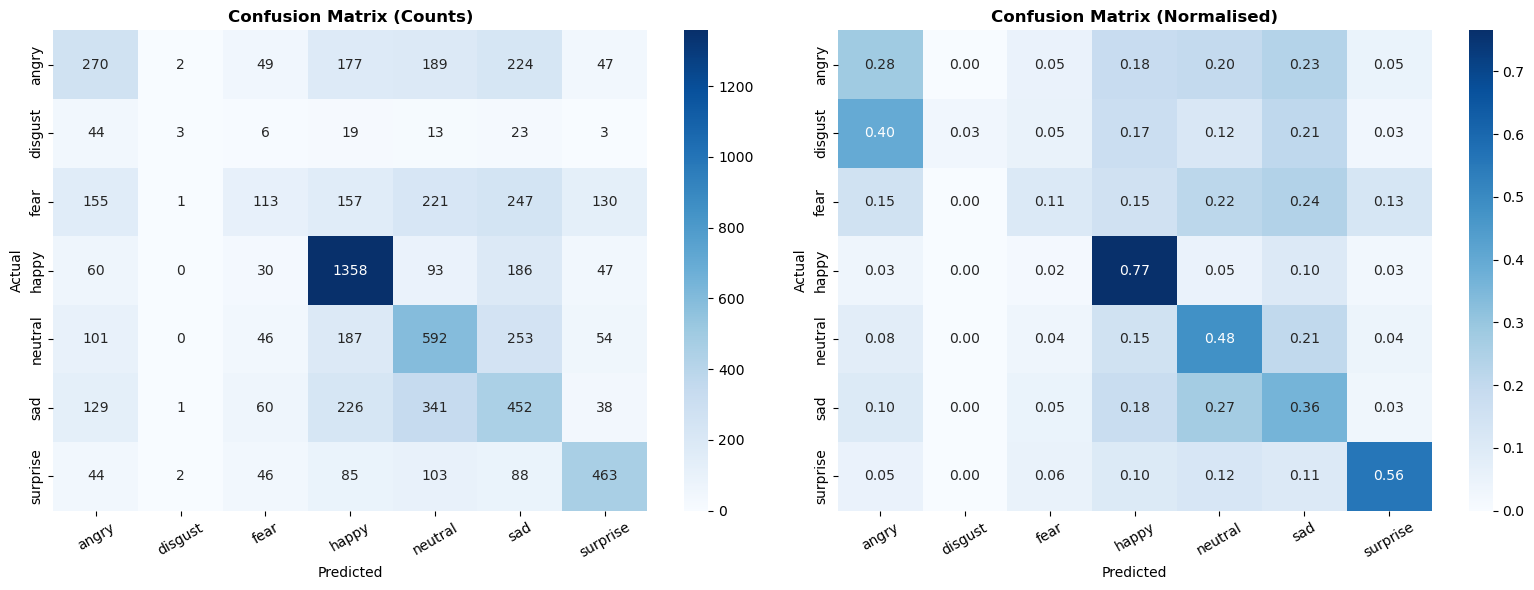

Saved → results/visualizations/confusion_matrix.png


In [12]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in [
    (axes[0], cm,'d','Confusion Matrix (Counts)'),
    (axes[1], cm_n, '.2f','Confusion Matrix (Normalised)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/visualizations/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/visualizations/confusion_matrix.png')

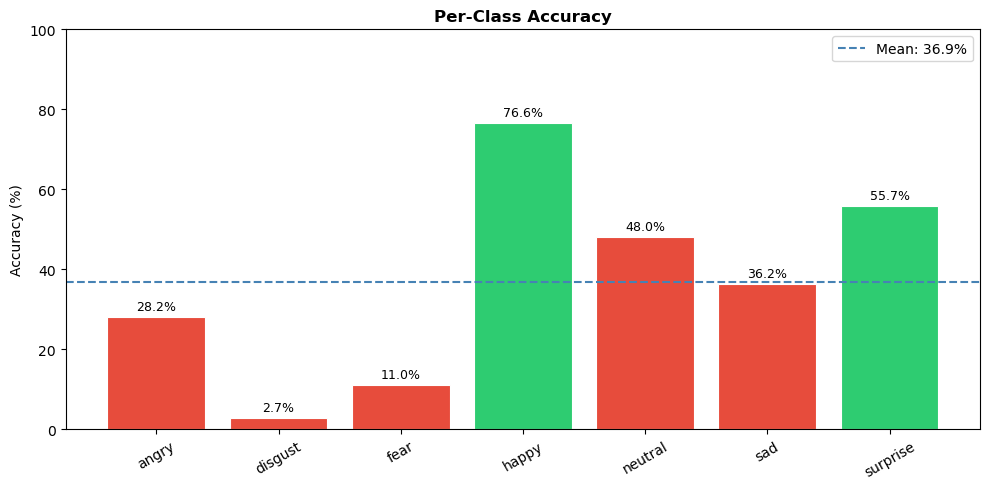

Saved  to results/visualizations/per_class_accuracy.png


In [13]:
# ── Per-class accuracy bar chart ──────────────────────────────────────────────
per_class_acc = cm_n.diagonal()

colours = ['#2ecc71' if a >= 0.5 else '#e74c3c' for a in per_class_acc]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colours, edgecolor='white', linewidth=0.8)
ax.axhline(y=per_class_acc.mean()*100, color='steelblue', linestyle='--', linewidth=1.5, label=f'Mean: {per_class_acc.mean()*100:.1f}%')
ax.set_title('Per-Class Accuracy', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=30)
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/visualizations/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved  to results/visualizations/per_class_accuracy.png')

### Static

In [14]:
# ── Initialise MediaPipe face detector ───────────────────────────────────────
base_options = python.BaseOptions(model_asset_path=BLAZEFACE_PATH)
options      = vision.FaceDetectorOptions(base_options=base_options)
detector     = vision.FaceDetector.create_from_options(options)
print('MediaPipe detector ready')

MediaPipe detector ready


In [16]:
# ── Inference helper ──────────────────────────────────────────────────────────
def predict_emotion(image_path: str) -> dict:
    """
    Full inference pipeline for a single image.
    Returns dict with: face_roi, predicted_class, confidence, all_probs
    """
    # 1. Read
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f'Cannot read: {image_path}')

    # 2. Face ROI
    rgb    = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = detector.detect(mp_img)

    if result.detections:
        bbox   = result.detections[0].bounding_box
        x1, y1 = max(0, bbox.origin_x), max(0, bbox.origin_y)
        x2, y2 = min(gray.shape[1], x1+bbox.width), min(gray.shape[0], y1+bbox.height)
        face   = gray[y1:y2, x1:x2]
        if face.size == 0:
            face = gray
    else:
        face = gray

    face_r = cv2.resize(face, FACE_SIZE)

    # 3. HOG
    feat = hog(face_r, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), block_norm='L2-Hys',
               transform_sqrt=True, feature_vector=True).astype('float32')

    # 4. Scale
    feat_scaled = scaler.transform(feat.reshape(1, -1))

    # 5. Predict
    probs      = model.predict(feat_scaled, verbose=0)[0]
    pred_idx   = probs.argmax()

    return {
        'face_roi'        : face_r,
        'predicted_class' : CLASS_NAMES[pred_idx],
        'confidence'      : float(probs[pred_idx]),
        'all_probs'       : {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)},
    }


def show_inference(image_path: str):
    """Visualise inference result for a single image."""
    result = predict_emotion(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Face
    axes[0].imshow(result['face_roi'], cmap='gray')
    axes[0].set_title(
        f"Predicted: {result['predicted_class'].upper()}\n"
        f"Confidence: {result['confidence']*100:.1f}%",
        fontweight='bold', fontsize=12
    )
    axes[0].axis('off')

    # Probability bar chart
    probs  = list(result['all_probs'].values())
    labels = list(result['all_probs'].keys())
    cols   = ['#2ecc71' if l == result['predicted_class'] else '#95a5a6' for l in labels]
    axes[1].barh(labels, probs, color=cols)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Class Probabilities', fontweight='bold')
    for i, v in enumerate(probs):
        axes[1].text(v + 0.01, i, f'{v*100:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

print('Inference functions defined')

Inference functions defined



── ANGRY ──


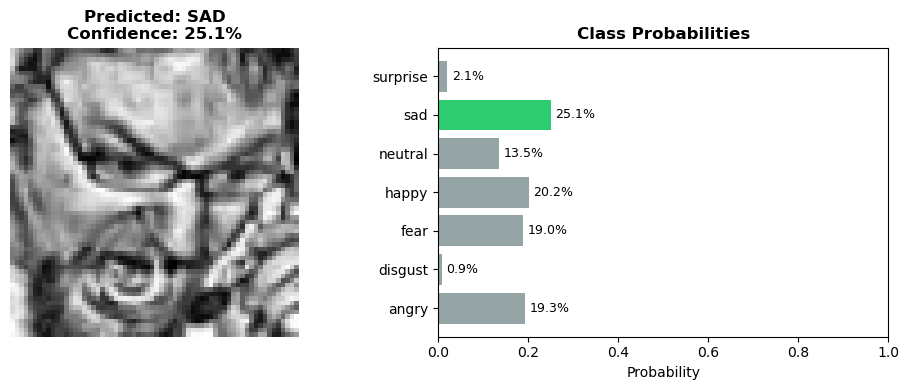


── DISGUST ──


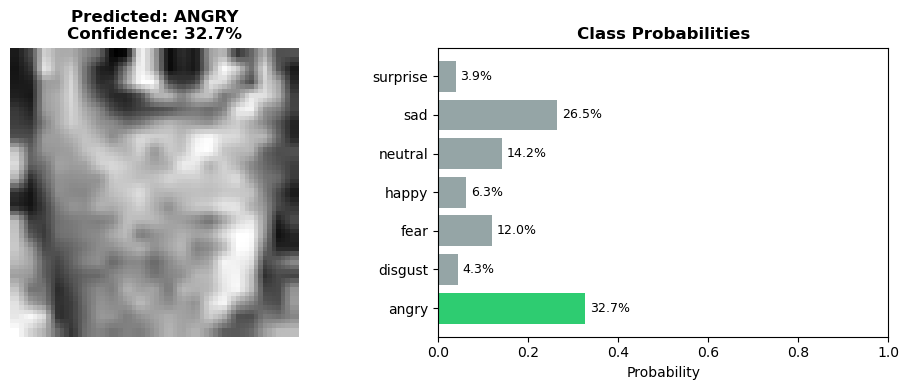


── FEAR ──


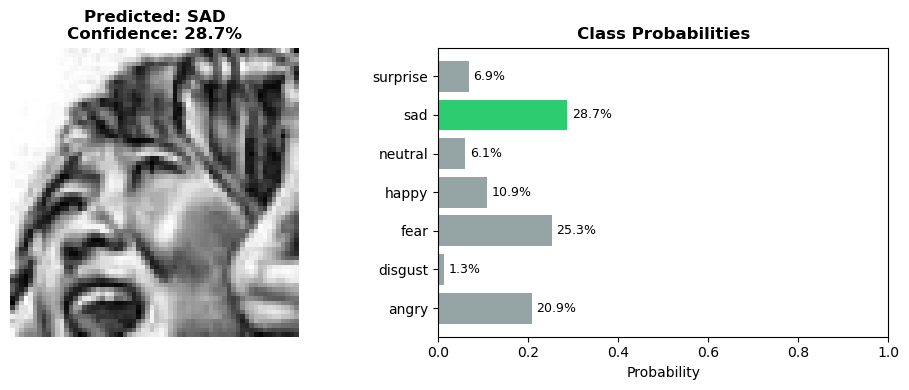


── HAPPY ──


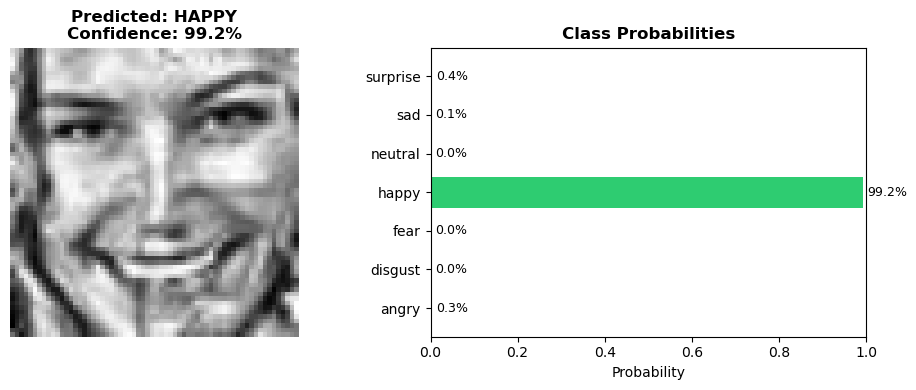


── NEUTRAL ──


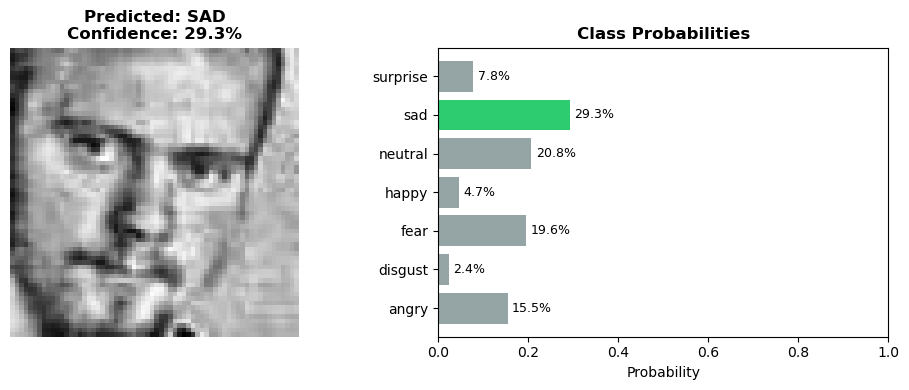


── SAD ──


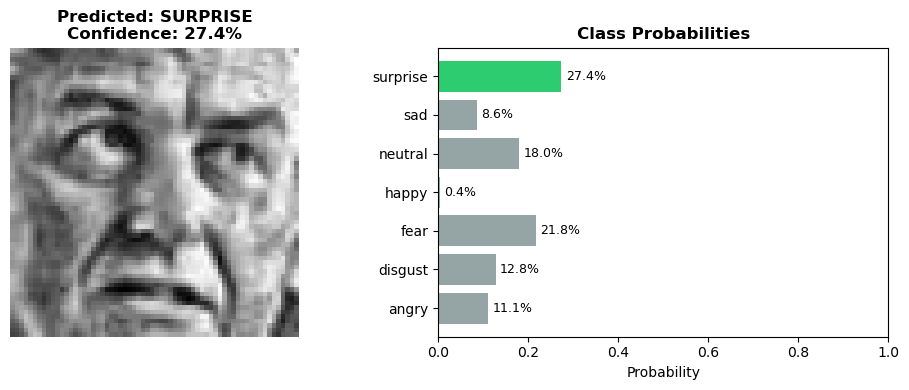


── SURPRISE ──


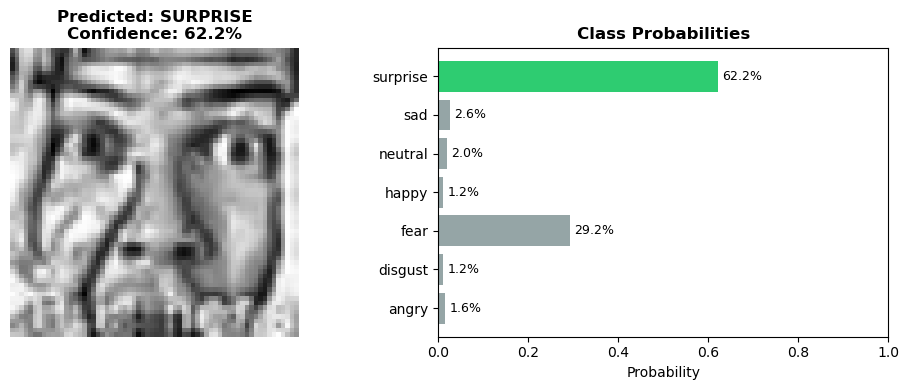

In [17]:
# ── Run on sample images (one per class) ──────────────────────────────────────
for cls in CLASS_NAMES:
    cls_dir   = os.path.join(TEST_PATH, cls)
    sample    = os.path.join(cls_dir, sorted(os.listdir(cls_dir))[0])
    print(f'\n── {cls.upper()} ──')
    show_inference(sample)

### web cam window

In [19]:
# PRESS Q TO QUIT IF YOU ARE STUCK 

EMOTION_COLORS = {
    'angry':    (0,   0,   255),
    'disgust':  (0,   140, 0  ),
    'fear':     (180, 0,   180),
    'happy':    (0,   200, 0  ),
    'neutral':  (200, 200, 200),
    'sad':      (255, 100, 0  ),
    'surprise': (0,   200, 200),
}

def run_webcam_demo():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print('Could not open webcam')
        return

    print('Webcam running — press Q to quit')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # MediaPipe detection
        rgb    = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_img)

        for det in result.detections:
            bbox = det.bounding_box
            x1, y1 = max(0, bbox.origin_x), max(0, bbox.origin_y)
            x2, y2 = min(gray.shape[1], x1+bbox.width), min(gray.shape[0], y1+bbox.height)

            face = gray[y1:y2, x1:x2]
            if face.size == 0:
                continue

            face_r = cv2.resize(face, FACE_SIZE)
            feat   = hog(face_r, orientations=9, pixels_per_cell=(8,8),
                         cells_per_block=(2,2), block_norm='L2-Hys',
                         transform_sqrt=True, feature_vector=True).astype('float32')
            feat_s = scaler.transform(feat.reshape(1, -1))
            probs  = model.predict(feat_s, verbose=0)[0]
            label  = CLASS_NAMES[probs.argmax()]
            conf   = probs.max()
            color  = EMOTION_COLORS[label]

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame,
                        f'{label} {conf*100:.0f}%',
                        (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        cv2.imshow('FER Demo — Q to quit', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print('Webcam demo ended')


run_webcam_demo()


Webcam running — press Q to quit
Webcam demo ended


In [20]:
# ── Print final summary table ─────────────────────────────────────────────────
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

print('=' * 55)
print('         FINAL RESULTS SUMMARY')
print('=' * 55)
print(f"  Overall Test Accuracy : {test_acc*100:.2f}%")
print(f"  Macro Avg F1-Score    : {report['macro avg']['f1-score']*100:.2f}%")
print(f"  Weighted Avg F1-Score : {report['weighted avg']['f1-score']*100:.2f}%")
print('-' * 55)
print(f"  {'Class':<12} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 55)
for cls in CLASS_NAMES:
    r = report[cls]
    print(f"  {cls:<12} {r['precision']*100:>9.1f}% {r['recall']*100:>7.1f}% {r['f1-score']*100:>7.1f}%")
print('=' * 55)

# ── List all saved visualizations ────────────────────────────────────────────
viz_dir = '../results/visualizations'
print('\nSaved visualizations:')
for f in sorted(os.listdir(viz_dir)):
    print(f'{os.path.join(viz_dir, f)}')

         FINAL RESULTS SUMMARY
  Overall Test Accuracy : 45.29%
  Macro Avg F1-Score    : 36.21%
  Weighted Avg F1-Score : 43.09%
-------------------------------------------------------
  Class         Precision   Recall       F1
-------------------------------------------------------
  angry             33.6%    28.2%    30.7%
  disgust           33.3%     2.7%     5.0%
  fear              32.3%    11.0%    16.4%
  happy             61.5%    76.6%    68.2%
  neutral           38.1%    48.0%    42.5%
  sad               30.7%    36.2%    33.2%
  surprise          59.2%    55.7%    57.4%

Saved visualizations:
../results/visualizations\class_distribution.png
../results/visualizations\confusion_matrix.png
../results/visualizations\hog_features_per_class.png
../results/visualizations\per_class_accuracy.png
../results/visualizations\preprocessing_before_after.png
